# Policy Gradient (REINFORCE) — An Illustrated Tour

> Optimise a **stochastic policy** $\pi_\theta(a \mid s)$ directly by gradient ascent on the expected return. No value function required.

---

**What we cover:**
- The objective $J(\theta) = \mathbb{E}\!\bigl[\sum_t \gamma^t r_t\bigr]$
- Likelihood-ratio (REINFORCE) gradient
- A baseline to reduce variance
- Training a categorical policy on CartPole with PyTorch
- Reward curve and action-probability evolution

## The picture — policy is a parametric distribution; push up actions with high return

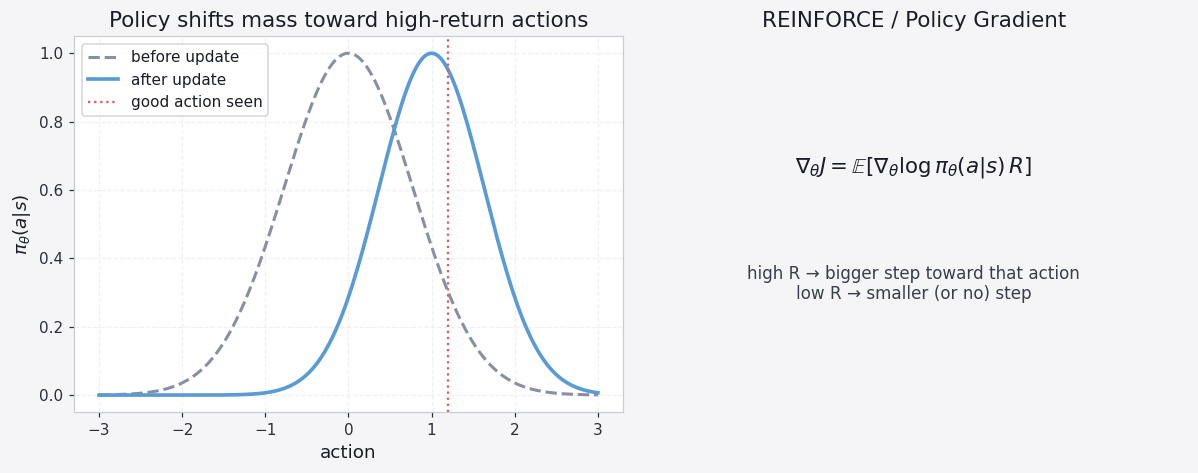

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax = axes[0]
a = np.linspace(-3, 3, 200); p1 = np.exp(-(a)**2/1.2); p1 /= p1.max()
p2 = np.exp(-(a-1.0)**2/0.8); p2 /= p2.max()
ax.plot(a, p1, color=P[6], lw=2, ls='--', label='before update')
ax.plot(a, p2, color=P[0], lw=2.4, label='after update')
ax.axvline(1.2, color=P[1], lw=1.5, ls=':', label='good action seen')
ax.set_xlabel('action'); ax.set_ylabel(r'$\pi_\theta(a|s)$')
ax.set_title('Policy shifts mass toward high-return actions')
ax.legend(); ax.grid(True)
ax = axes[1]
ax.text(0.5, 0.65, r'$\nabla_\theta J = \mathbb{E}[\nabla_\theta \log\pi_\theta(a|s)\,R]$',
        ha='center', va='center', fontsize=14)
ax.text(0.5, 0.30, 'high R → bigger step toward that action\nlow R → smaller (or no) step',
        ha='center', fontsize=11, color='#3a3e4a')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
ax.set_title('REINFORCE / Policy Gradient')
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

torch.manual_seed(0); np.random.seed(0)
env = gym.make('CartPole-v1')
n_obs = env.observation_space.shape[0]
n_act = env.action_space.n

---
## The Policy Gradient Theorem

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\!\Bigl[\sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t)\, G_t\Bigr],$$

where $G_t = \sum_{k\geq t} \gamma^{k-t} r_k$ is the discounted return from step $t$. Intuitively: **push up** the log-probability of actions whose return turned out high, **push down** those whose return was low.

Variance is huge with raw $G_t$. Subtract a **baseline** $b_t$ (often the empirical mean / std) without changing the expectation:

$$\nabla_\theta J \approx \sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t) \,(G_t - b_t).$$

In [3]:
class Policy(nn.Module):
    def __init__(self, n_in, n_out, h=64):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(n_in, h), nn.Tanh(),
                                nn.Linear(h, h),    nn.Tanh(),
                                nn.Linear(h, n_out))
    def forward(self, x): return self.f(x)

pi = Policy(n_obs, n_act)
opt = torch.optim.Adam(pi.parameters(), lr=3e-3)
gamma = 0.99

def play_episode(seed):
    s, _ = env.reset(seed=seed)
    log_probs = []; rewards = []; probs_traj = []
    for _ in range(500):
        st = torch.tensor(s, dtype=torch.float32)
        logits = pi(st)
        dist = Categorical(logits=logits)
        a = dist.sample()
        log_probs.append(dist.log_prob(a))
        probs_traj.append(F.softmax(logits, -1).detach().numpy())
        s, r, term, trunc, _ = env.step(int(a.item()))
        rewards.append(r)
        if term or trunc: break
    return log_probs, rewards, np.array(probs_traj)

def update(log_probs, rewards):
    G = 0; returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)   # baseline
    loss = -torch.stack([lp * R for lp, R in zip(log_probs, returns)]).sum()
    opt.zero_grad(); loss.backward(); opt.step()

ep_returns = []
early_traj = None; late_traj = None
for ep in range(400):
    lp, r, traj = play_episode(seed=ep)
    update(lp, r)
    ep_returns.append(sum(r))
    if ep == 5:   early_traj = traj
    if ep == 399: late_traj = traj
print('Final 25-ep mean return:', np.mean(ep_returns[-25:]))

Final 25-ep mean return: 500.0


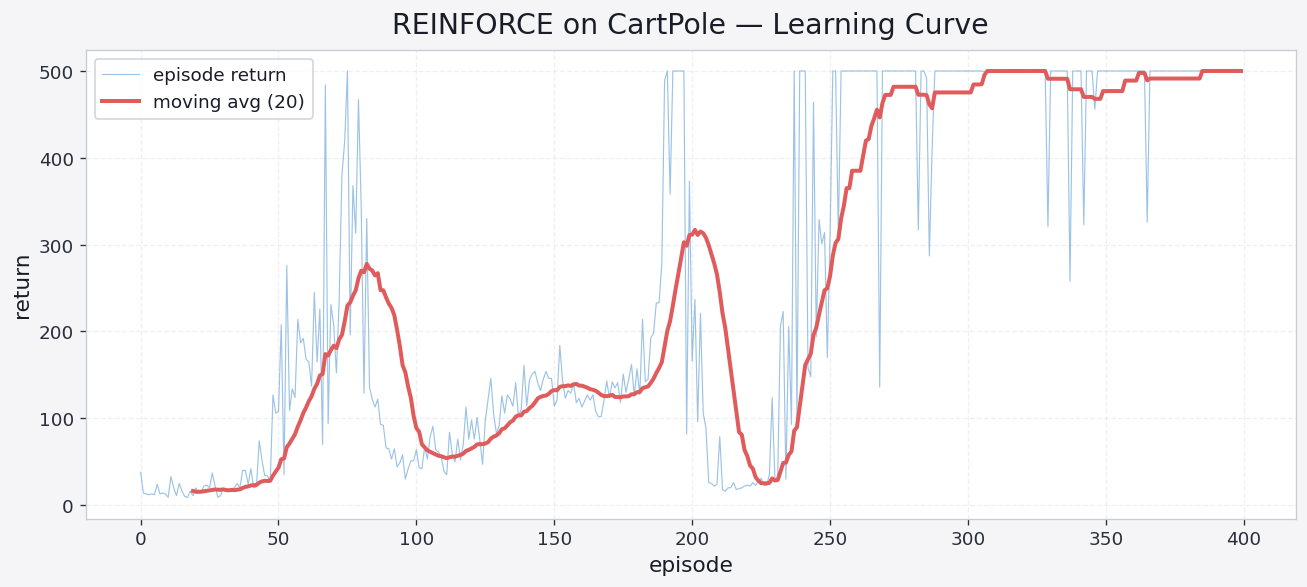

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ep_returns, color=C0, lw=0.7, alpha=0.6, label='episode return')
w = 20
ax.plot(np.arange(w-1, len(ep_returns)),
        np.convolve(ep_returns, np.ones(w)/w, 'valid'),
        color=C1, lw=2.4, label=f'moving avg ({w})')
ax.set_xlabel('episode'); ax.set_ylabel('return')
ax.set_title('REINFORCE on CartPole — Learning Curve', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Action-Probability Evolution

Early in training the policy is near-uniform (entropy = log 2). Once the agent has discovered which way to push the cart, the probabilities sharpen toward 0/1 in response to the pole's tilt.

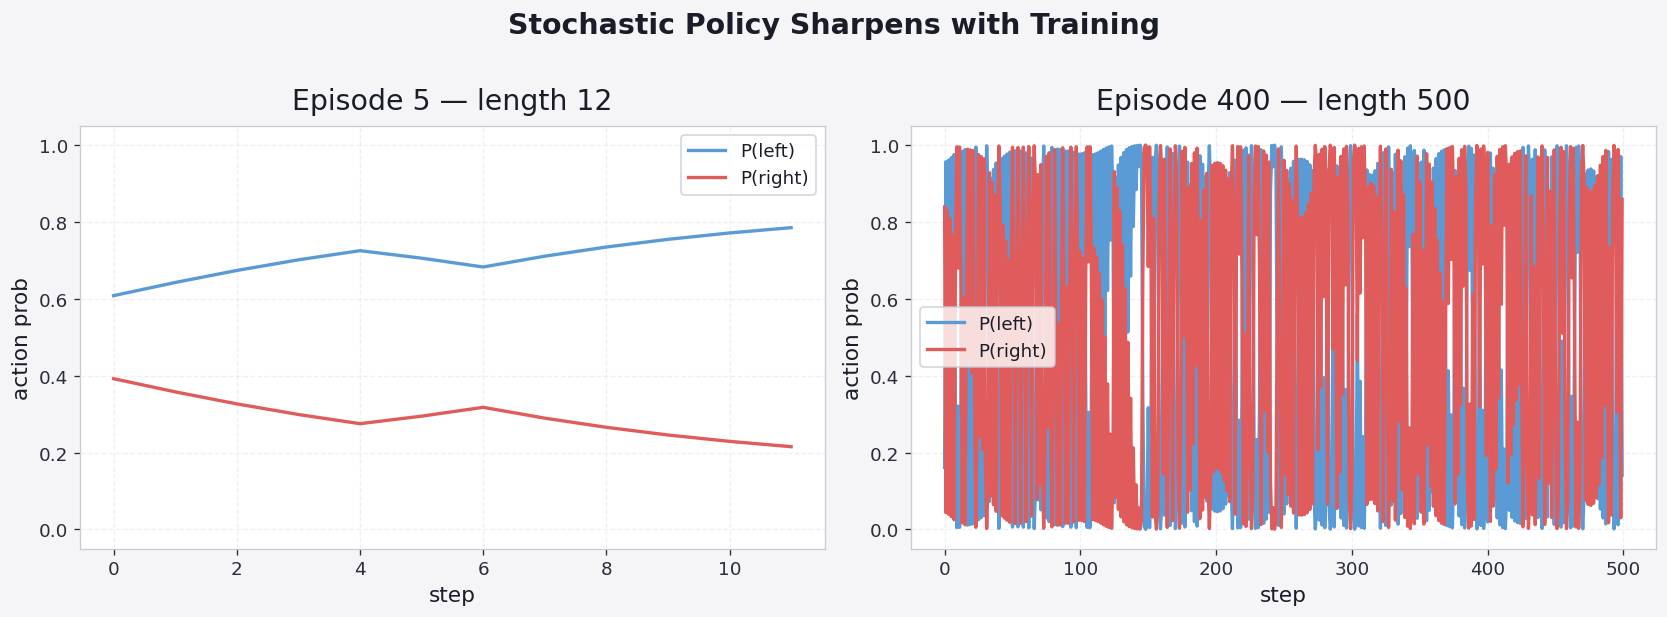

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, traj, title in zip(axes, [early_traj, late_traj], ['Episode 5', 'Episode 400']):
    ax.plot(traj[:, 0], color=C0, lw=2, label='P(left)')
    ax.plot(traj[:, 1], color=C1, lw=2, label='P(right)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{title} — length {len(traj)}', pad=10)
    ax.set_xlabel('step'); ax.set_ylabel('action prob'); ax.legend(); ax.grid(True)
fig.suptitle('Stochastic Policy Sharpens with Training', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use REINFORCE / PG — and when not to

| Situation | REINFORCE | DQN | A2C / PPO | Evolution strategies |
|---|---|---|---|---|
| Continuous actions | ✅ | ❌ | ✅ | ✅ |
| Discrete actions | ✅ | ✅ usually better | ✅ | ✅ |
| Need low-variance gradient | ❌ very noisy | ✅ | ✅ baseline + GAE | partial |
| Black-box / non-differentiable env | ✅ | ✅ | ✅ | ✅ |

> Plain REINFORCE is **mostly pedagogical**. In practice, always add a baseline (A2C) or trust-region update (PPO).


---
## 🎯 Try this

1. **Add a baseline.** Subtract a moving average return from $G_t$ — variance of the gradient should drop several-fold; learning curve becomes smoother.
2. **Entropy bonus.** Add $\beta \mathcal{H}(\pi_\theta(\cdot \mid s))$ to the loss with $\beta=0.01$. Premature determinism is a classic PG failure; this fixes it.
3. **Generalised advantage estimation.** Replace $G_t$ with $\sum_k (\gamma\lambda)^k \delta_{t+k}$ where $\delta = r + \gamma V(s') - V(s)$. With a small value net, this is the leap from REINFORCE to A2C.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Stochastic policy | $\pi_\theta(a \mid s)$ | Differentiable; samples actions |
| Score function | $\nabla_\theta \log \pi_\theta(a \mid s)$ | Likelihood-ratio trick |
| Return $G_t$ | Discounted sum from $t$ | Drives the gradient |
| Baseline | Subtract a state-only term | Reduces variance, no bias |
| Strength | Works for **continuous** action spaces; on-policy stable | Foundation for A2C, PPO, TRPO |
| Weakness | High variance; sample-inefficient (on-policy only) | Use baselines / actor-critic / GAE |

**Bottom line:** Policy gradient walks **uphill in the policy space** itself. Each episode is a tiny Monte-Carlo estimate of $\nabla J$; modern algorithms (PPO, SAC, A3C) keep the same backbone but tame the variance.